In [15]:
from variable_leverage_env_3 import agentDLVEnvV3
from torch_model_v2 import reccurentActor
import pandas as pd
import numpy as np
from utils import plot_episode_history_v2

In [16]:
import matplotlib.pyplot as plt

def plot_economic_metrics(histories, labels, top_leverage, bottom_leverage, mic_cr = 1.2, name = None):
    n = len(histories)

    fig, axs = plt.subplots(10, 1, figsize=(12, 20), sharex=True)

    if 'timestamp' in histories[0]:
        timestamp = histories[0]['timestamp']
        timestamp = np.array(timestamp)
        date = timestamp.astype("datetime64[s]")
        fig.supxlabel('date')
    else:
        fig.supxlabel('step')
        date = None

    if date is not None:
        for i in range(n):
            axs[0].plot(date, histories[i]['leverage'], label = labels[i])
    else:
        for i in range(n):
            axs[0].plot(histories[i]['leverage'], label = labels[i])
    axs[0].axhline(top_leverage, color='r', linestyle='--', label='leverage boundary')
    axs[0].axhline(bottom_leverage, color='r', linestyle='--')
    axs[0].set_ylabel('leverage')
    axs[0].legend()
    
    if date is not None:
        for i in range(n):
            axs[1].plot(date, histories[i]['PNL'], label = labels[i])
    else:
        for i in range(n):
            axs[1].plot(histories[i]['PNL'], label = labels[i])
    axs[1].set_ylabel('PNL (in usd)')
    axs[1].legend()

    if date is not None:
        for i in range(n):
            axs[2].plot(date, histories[i]['return'], label = labels[i])
    else:
        for i in range(n):
            axs[2].plot(histories[i]['return'], label = labels[i])
    axs[2].set_ylabel('return, %')
    axs[2].legend()

    if date is not None:
        for i in range(n):
            axs[3].plot(date, histories[i]['collaterization ratio'], label = labels[i])
    else:
        for i in range(n):
            axs[3].plot(histories[i]['collaterization ratio'], label = labels[i])
    axs[3].axhline(mic_cr, color='r', linestyle='--', label='minimal cr')
    axs[3].set_ylabel('collaterization ratio')
    axs[3].legend()

    if date is not None:
        for i in range(n):
            axs[4].plot(date, histories[i]['vol token amount'], label = labels[i])
    else:
        for i in range(n):
            axs[4].plot(histories[i]['vol token amount'], label = labels[i])
    axs[4].set_ylabel('volatile token amount')
    axs[4].legend()

    if date is not None:
        for i in range(n):
            axs[5].plot(date, histories[i]['nect debt'], label = labels[i])
    else:
        for i in range(n):
            axs[5].plot(histories[i]['nect debt'], label = labels[i])
    axs[5].set_ylabel('total debt value (in usd)')
    axs[5].legend()

    if date is not None:
        for i in range(n):
            axs[6].plot(date, histories[i]['vol token price'], label = labels[i])
    else:
        for i in range(n):
            axs[6].plot(histories[i]['vol token price'], label = labels[i])
    axs[6].set_ylabel('volatile token price (in usd)')
    axs[6].legend()

    if date is not None:
        for i in range(n):
            axs[7].plot(date, histories[i]['total loss'], label = labels[i])
    else:
        for i in range(n):
            axs[7].plot(histories[i]['total loss'], label = labels[i])
    axs[7].set_ylabel('relative transaction losses')
    axs[7].legend()

    if date is not None:
        for i in range(n):
            axs[8].plot(date, histories[i]['nav'], label = labels[i])
    else:
        for i in range(n):
            axs[8].plot(histories[i]['nav'], label = labels[i])
    axs[8].set_ylabel('LP token nav (in usd)')
    axs[8].legend()

    if date is not None:
        for i in range(n):
            axs[9].plot(date, histories[i]['calm part'], label = labels[i])
    else:
        for i in range(n):
            axs[9].plot(histories[i]['calm part'], label = labels[i])
    axs[9].set_ylabel('LP token calm part, %')
    axs[9].legend()

    if name is not None:
        fig.suptitle("name")

    plt.tight_layout()
    plt.show()

In [17]:
def naiveAgent(obs, min_cr=1.2, eps=1e-9):
    leverage = obs[0]
    cr = 1/obs[1]

    if cr <= min_cr + 0.03:
        return 1
    if leverage >= 0.95 or leverage <= 0.05:
        return 1
    else:
        return 0

In [18]:
model = reccurentActor()
model.set_initial_state('actor_weights_v2.pth')

In [19]:
WIDTH = 0.4
TOP_LEVERAGE = 2 + WIDTH/2
BOTTOM_LEVERAGE = 2 - WIDTH/2

df = pd.read_csv('wbtc_test_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values
timestamp = df['timestamp'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]
timestamp = timestamp[::4]

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
doing nothing 99.90036532713384 %
action 1 0.09963467286615742 %
action 2 0.0 %
action 3 0.0 %


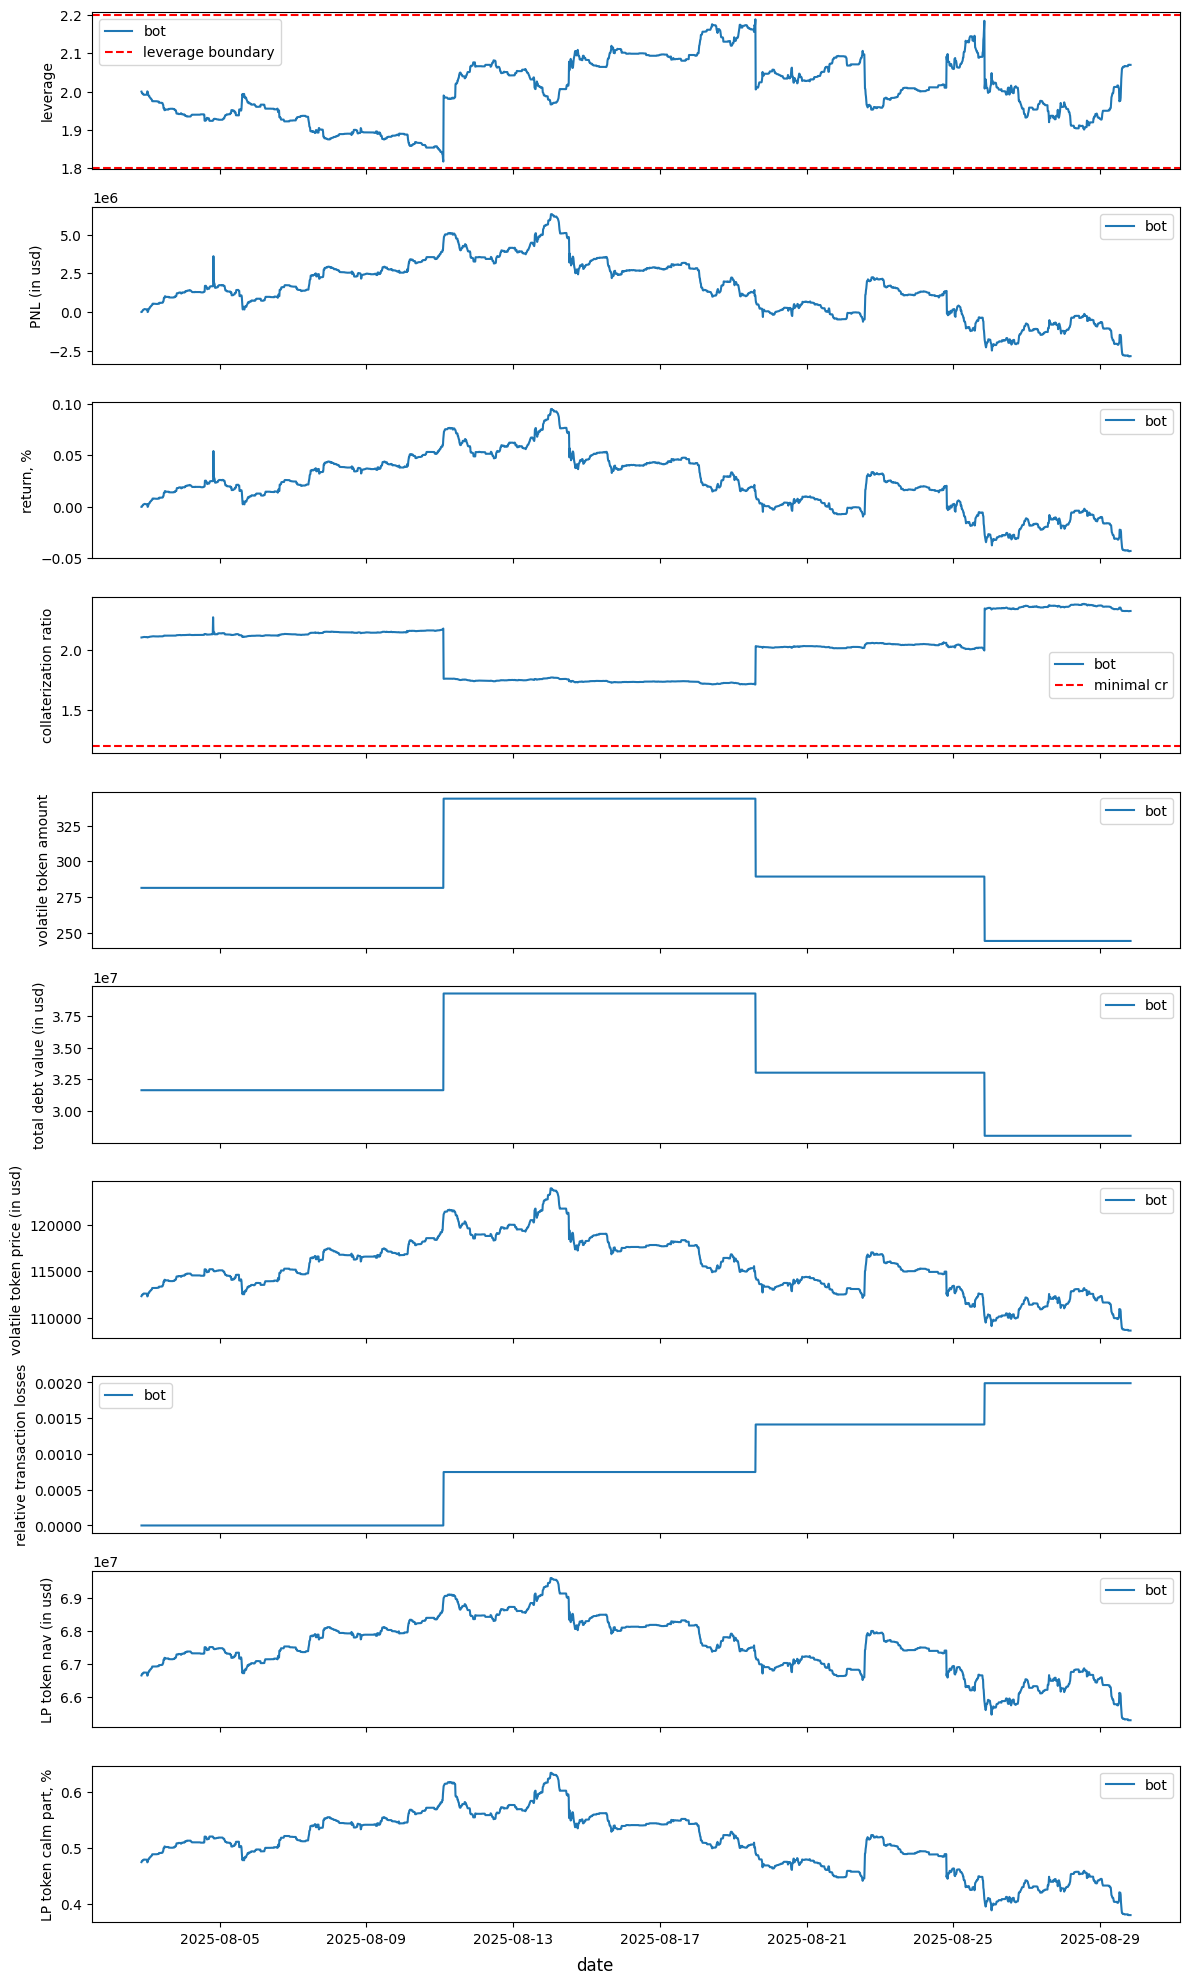

In [20]:
eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = False,
    is_reversed = False,
    top_leverage= TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)

obs, _ = eval_env.reset()
done = False

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

agent_history = info['episode_history']
agent_history_metrics = info['episode_metrics']
agent_economic_metrics = info['episode_economics']
t_l = info['top leverage']
b_l = info['bottom leverage']
not_doing = info.get('0 action')  
action_1 = info.get('0.5 rebalancing') 
action_2 = info.get('0.75 rebalancing') 
action_3 = info.get('0.25 rebalancing') 

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

agent_economic_metrics['timestamp'] = timestamp

plot_economic_metrics(
    [agent_economic_metrics],
    ['bot'],
    TOP_LEVERAGE,
    BOTTOM_LEVERAGE
)

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
doing nothing 99.90036532713384 %
action 1 0.06642311524410495 %
action 2 0.033211557622052475 %
action 3 0.0 %


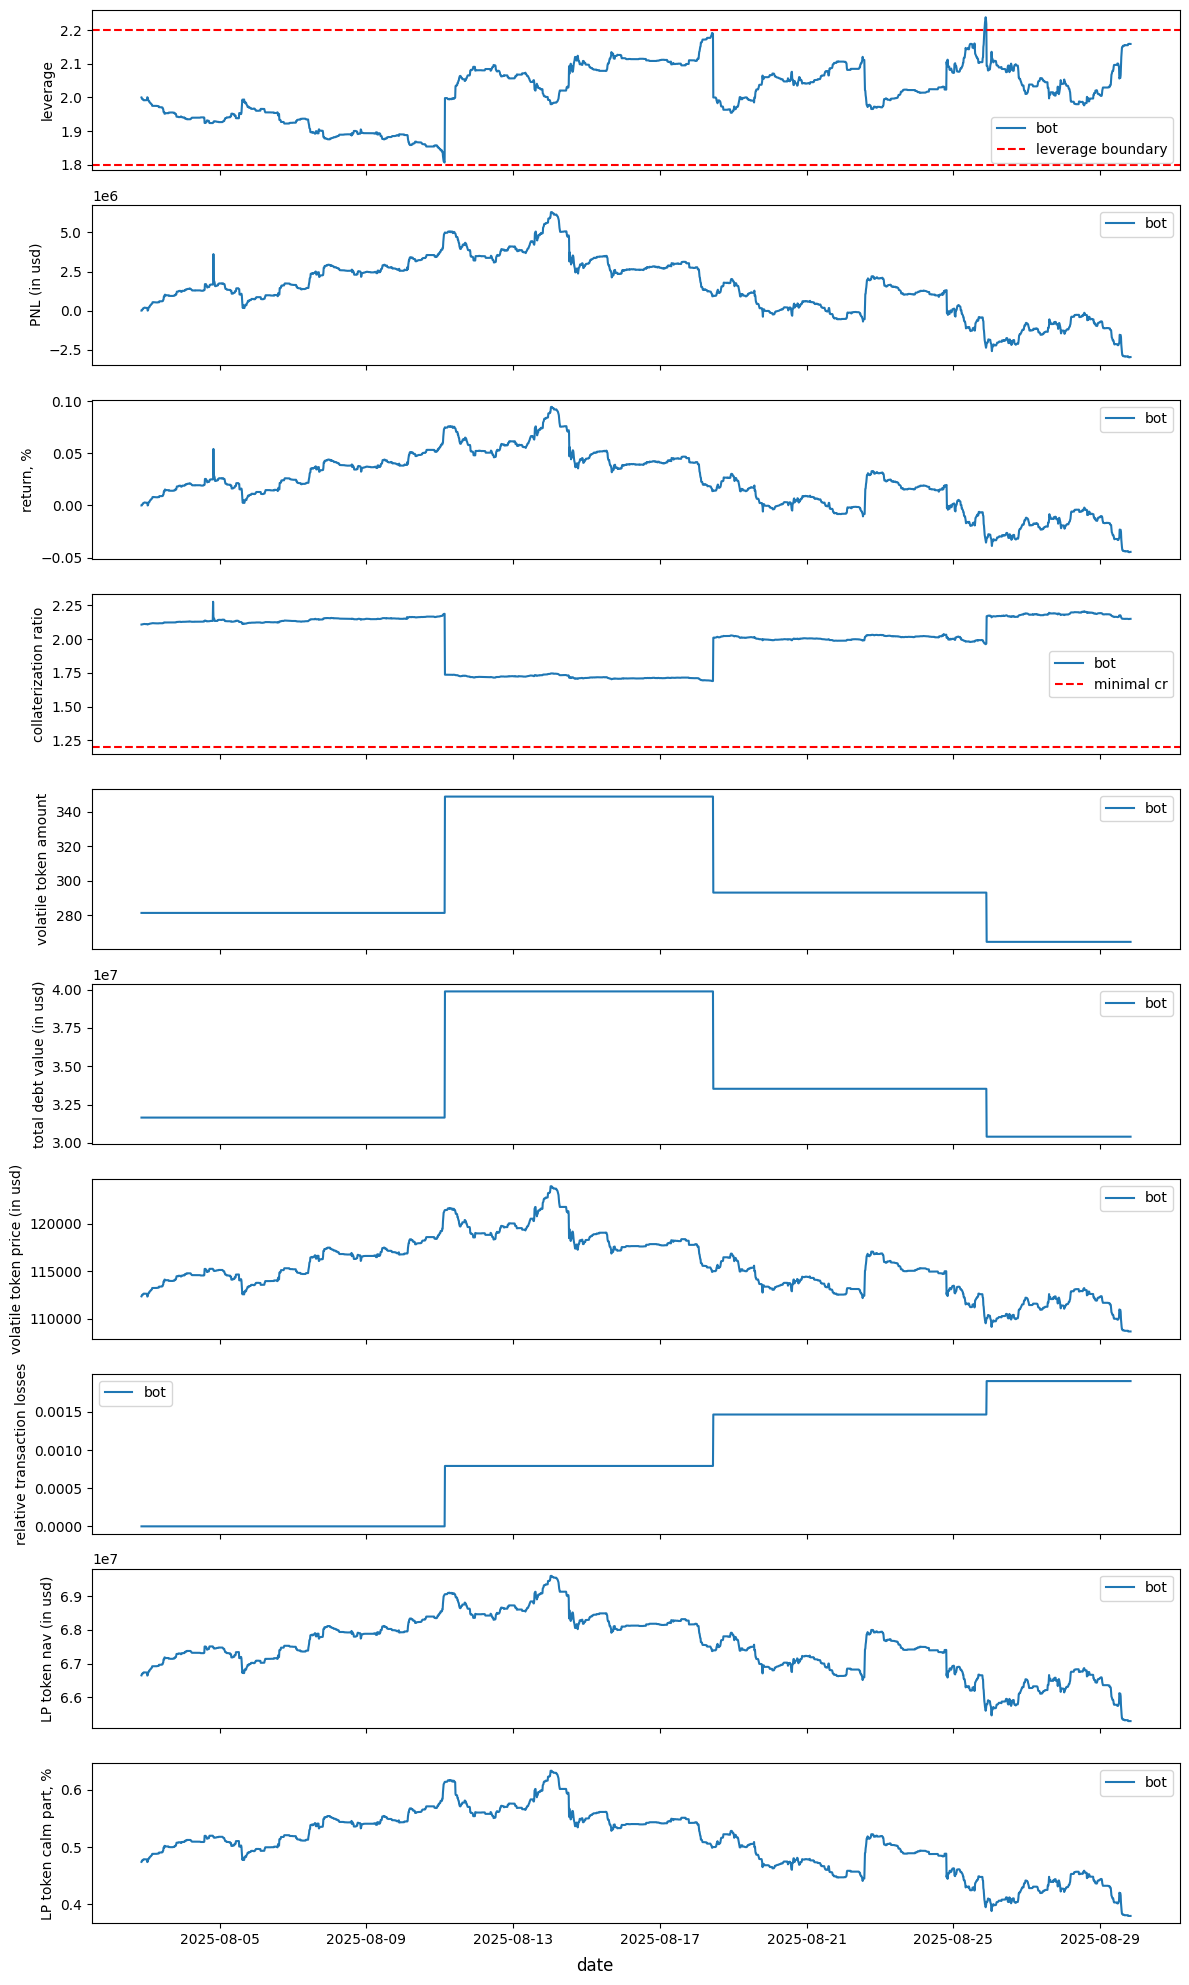

In [21]:
eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = False,
    is_mixed = False,
    is_reversed = False,
    top_leverage= TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)

obs, _ = eval_env.reset()
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    action, log_prob, _, hidden = model.act(obs, hidden)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

bot_history = info['episode_history']
bot_history_metrics = info['episode_metrics']
bot_economic_metrics = info['episode_economics']
t_l = info['top leverage']
b_l = info['bottom leverage']
not_doing = info.get('0 action')  
action_1 = info.get('0.5 rebalancing') 
action_2 = info.get('0.75 rebalancing') 
action_3 = info.get('0.25 rebalancing') 

print('doing nothing', not_doing*100, '%')
print('action 1', action_1*100, '%')
print('action 2', action_2*100, '%')
print('action 3', action_3*100, '%')

bot_economic_metrics['timestamp'] = timestamp

plot_economic_metrics(
    [bot_economic_metrics],
    ['bot'],
    TOP_LEVERAGE,
    BOTTOM_LEVERAGE
)


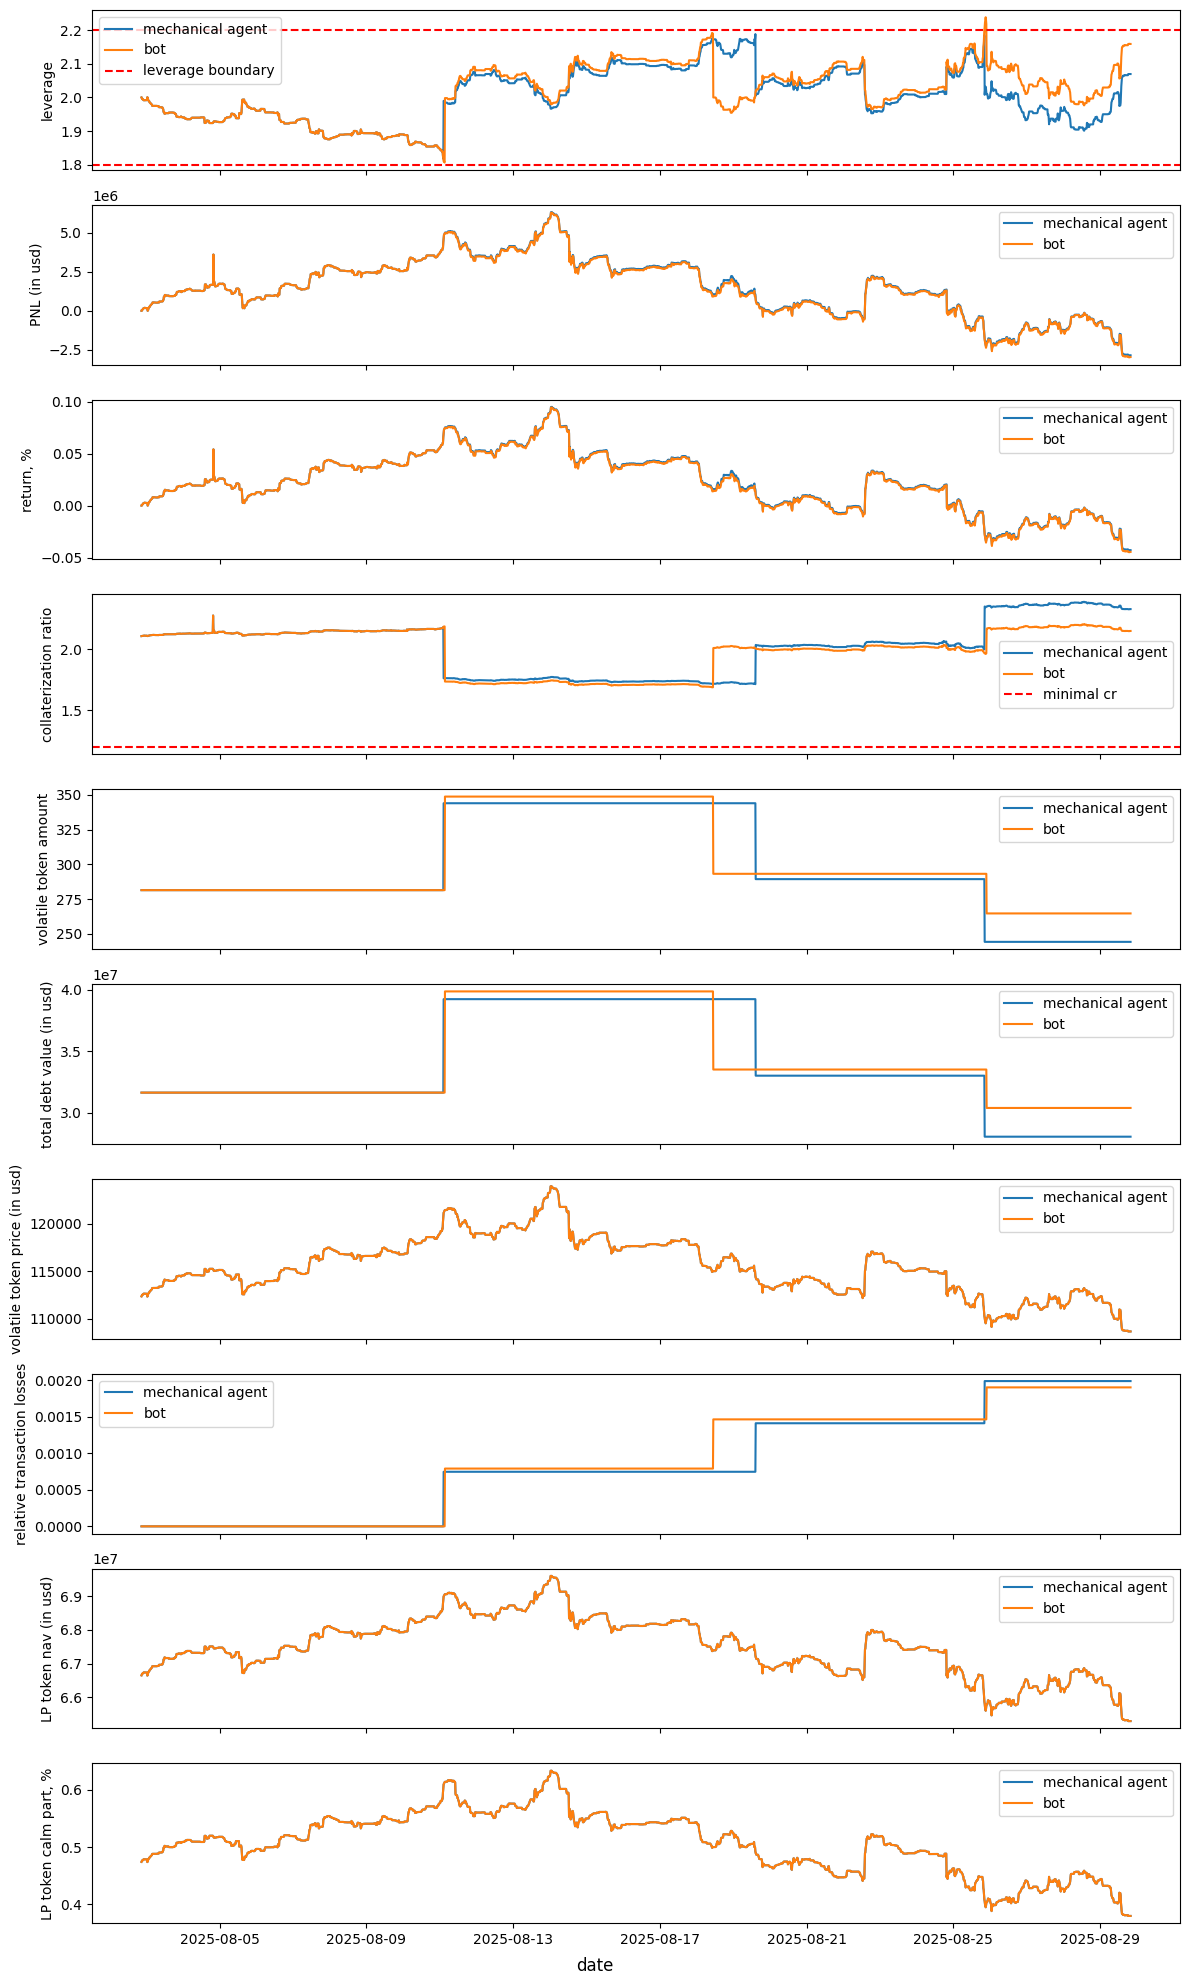

In [22]:
plot_economic_metrics(
    [agent_economic_metrics, bot_economic_metrics],
    ['mechanical agent', 'bot'],
    TOP_LEVERAGE,
    BOTTOM_LEVERAGE
)

In [23]:


eval_env = agentDLVEnvV3(
    nect_honey_price = nect_price,
    nav_in_honey = nav,
    vol_part = volatile_part,
    vol_token_honey_price = vol_token_price,
    is_training = True,
    is_mixed = True,
    is_reversed = True,
    index=True,
    top_leverage= TOP_LEVERAGE,
    bottom_leverage = BOTTOM_LEVERAGE
)

obs, _ = eval_env.reset(seed=400)
done = False
hidden = model.init_hidden(batch_size=1, device='cpu')

while not done:
    action, log_prob, _, hidden = model.act(obs, hidden)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

a1 = info['loss_rate']
loss1 = info['losses']

obs, _ = eval_env.reset(seed=400)
done = False

while not done:
    action = naiveAgent(obs)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    done = terminated or truncated

a2 = info['loss_rate']
loss2 = info['losses']

action scale 1
primordial penalty 0.25
penalty damping 0.9
reward scale 1
reward bound 5
loss scale 0
liquidation penalty 0
risk coef 0
boundary reward scale 0
idle reward 0.05
rebalancing reward 0.2
extravagance penalty 0.1
Env True rng test: 0.1990988109705989
Env True rng test: 0.1990988109705989


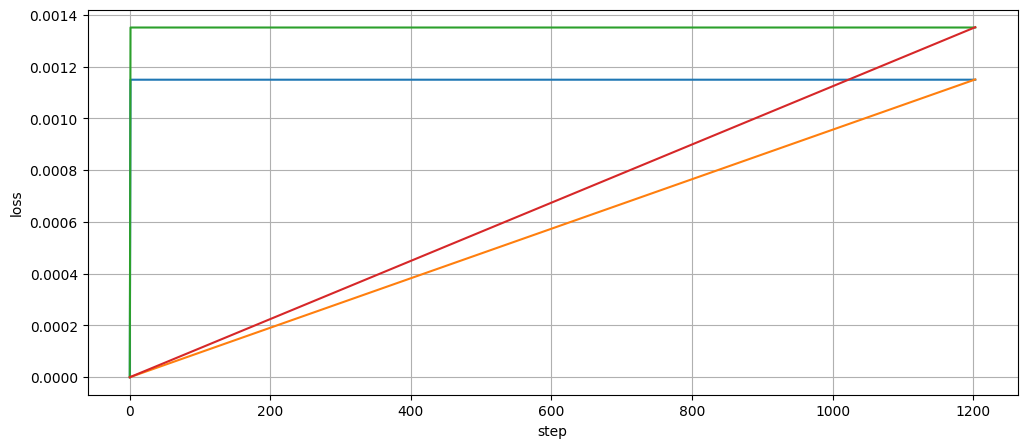

In [24]:


time = np.arange(len(info['losses']))

plt.figure(figsize=(12, 5))
plt.plot(time, loss1)
plt.plot(time, time*a1)
plt.plot(time, loss2)
plt.plot(time, time*a2)
plt.xlabel('step')
plt.ylabel('loss')
plt.grid(True)
plt.show()